# Asyncio in Python 

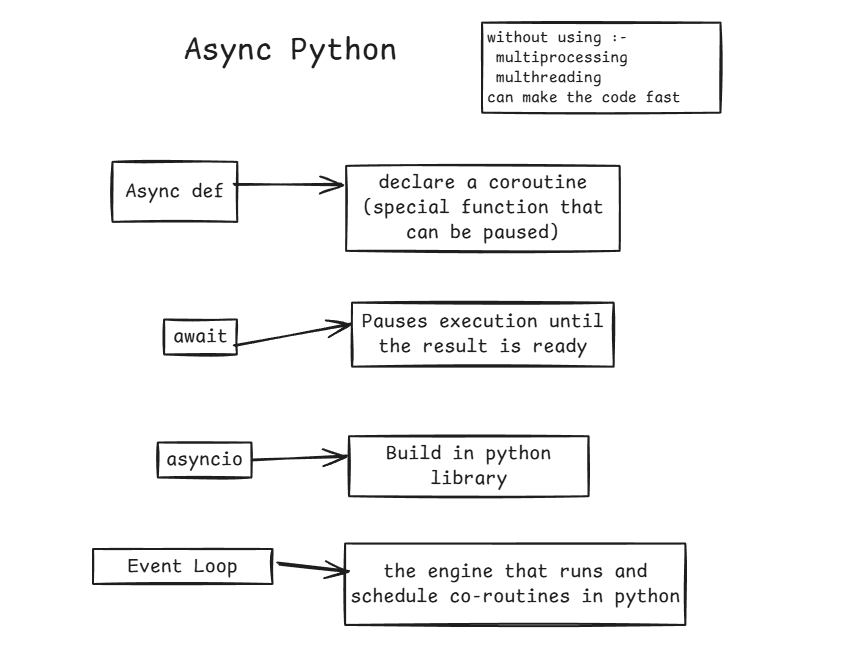

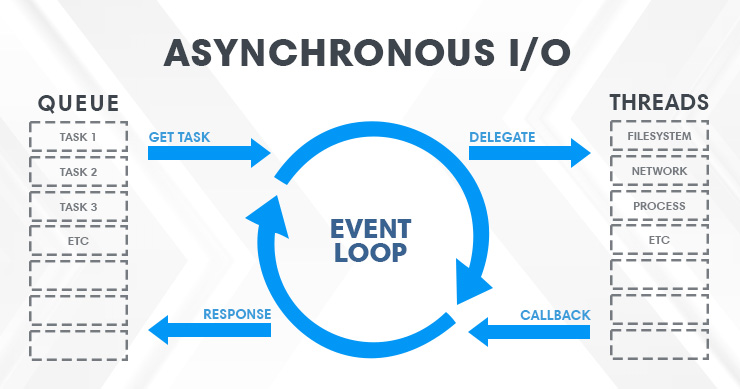

In [ ]:
import asyncio


async def brew_chai():
    print('Brewing chai...')
    await asyncio.sleep(2)
    print("Chai is ready!")

asyncio.run(brew_chai())
# A simple asynchronous function to simulate brewing chai tea.
# It waits for 2 seconds to mimic the brewing time before printing that the chai is ready.
# This demonstrates the use of asyncio for asynchronous programming in Python.
# This script uses asyncio to run the brew_chai function asynchronously.


### Example 2


In [ ]:
import asyncio
import time

async def brew(name):
    print(f'Brewing {name}...')
    await asyncio.sleep(3)
    # time.sleep(3)
    print(f'{name} is ready!')

async def main():
    await asyncio.gather(
        brew("Masala Chai"),
        brew('ginger tea'),
        brew('lemon tea')
    )


asyncio.run(main())

## Aynscio Http (aiohttp)

---
**Documentation:** https://docs.aiohttp.org/en/stable/


In [ ]:
import asyncio
import aiohttp 


async def fetch_url(session,url):
    async with session.get(url) as response:
        print(f'Fetched {url} with status {response.status}')

async def main():
    urls=['http://httpbin.org/delay/2'] * 3
    async with aiohttp.ClientSession() as session:
        tasks= [fetch_url(session,url) for url in urls]
        await asyncio.gather(*tasks) # '*' means unpacking the list of tasks into individual arguments for gather

asyncio.run(main())

## Asyncio with multithreading

In [ ]:
import asyncio
import time
from concurrent.futures import ThreadPoolExecutor

def check_Stock(item):
    print(f'Checking {item} in store...')
    time.sleep(2)
    return f'{item} stock :42'

async def main():
    loop = asyncio.get_running_loop()
    with ThreadPoolExecutor() as pool:
        result= await loop.run_in_executor(pool,check_Stock,'Masala Chai')
        print(result)

    
asyncio.run(main())

In [ ]:
import asyncio
import threading
import time


def background_worker():
    while True:
        time.sleep(1)
        print(f'Logging the system health 🕰️')


async def fetch_orders():
    await asyncio.sleep(3)
    print('Order fetched! 🛒')


threading.Thread(target=background_worker,daemon=True).start()

asyncio.run(fetch_orders())

## Async with multiprocessing

In [ ]:
import asyncio
from concurrent.futures import ProcessPoolExecutor


def encrypt(data):
    return f'🔒 {data[::-1]}'

async def main():
   loop = asyncio.get_running_loop() 
   with ProcessPoolExecutor() as pool:
       result = await loop.run_in_executor(pool,encrypt,'secret data')
       print(result)


if __name__ == "__main__":
    asyncio.run(main())


## Daemon Vs Non Daemon Threads

**Daemon Threads:**
- Background threads that automatically terminate when the main program exits
- Do not prevent the program from exiting
- Useful for background tasks like logging, monitoring, or periodic cleanup
- Set with `daemon=True` parameter when creating a thread

**Non-Daemon Threads:**
- Regular threads that keep the program running until they complete
- The program waits for all non-daemon threads to finish before exiting
- Default behavior when creating threads (`daemon=False`)
- Used for critical tasks that must complete before program termination

### DAEMON 

# Daemon Thread Execution Timeline

## Code Analysis
```python
import threading
import time

def monitor_tea_temp():
    while True:
        print(f"Monitoring tea temperature... ")
        time.sleep(3)  # Sleep for 3 seconds

t = threading.Thread(target=monitor_tea_temp, daemon=True)
t.start()
time.sleep(5)  # Main thread sleeps for 5 seconds
print("Main Program Done")
```

## Execution Timeline

| Time | Main Thread | Daemon Thread | Output |
|------|-------------|---------------|--------|
| **0.0s** | Creates daemon thread | - | |
| **0.0s** | Calls `t.start()` | Thread starts | |
| **0.001s** | Starts `time.sleep(5)` | Prints "Monitoring..." | `Monitoring tea temperature...` |
| **0.001s** | (sleeping...) | Starts `time.sleep(3)` | |
| **3.0s** | (still sleeping...) | Wakes up from sleep | |
| **3.0s** | (still sleeping...) | Loops back to `while True` | |
| **3.0s** | (still sleeping...) | Prints "Monitoring..." | `Monitoring tea temperature...` |
| **3.001s** | (still sleeping...) | Starts `time.sleep(3)` again | |
| **5.0s** | Wakes up from sleep | (sleeping...) | |
| **5.001s** | Prints "Main Program Done" | (sleeping...) | `Main Program Done` |
| **5.002s** | Reaches end of script | (sleeping...) | |
| **5.002s** | **EXITS** | **KILLED immediately** | |

## Expected Output
```
Monitoring tea temperature... 
Monitoring tea temperature... 
Main Program Done
```

## Key Points

### Why Only 2 Prints?

1. **First print (at ~0s):** Daemon thread prints immediately after starting
2. **Second print (at 3s):** Daemon thread wakes up, loops, and prints again
3. **Main finishes (at 5s):** Main thread wakes up and prints "Main Program Done"
4. **Daemon killed (at 5s):** Python immediately terminates the daemon thread mid-sleep (it was only 2 seconds into its 3-second sleep)

### Why Daemon Thread Stops

The daemon thread would have printed again at **6 seconds**, but the main program exits at **5 seconds**. 

**Daemon threads are forcefully terminated when the main program ends**, regardless of what they're doing (even if they're in the middle of sleeping or processing).

## Comparison: Daemon vs Non-Daemon

### With `daemon=True` (Current Code)
- Main program exits at 5 seconds
- Daemon thread is killed immediately
- Program terminates cleanly
- Total runtime: **~5 seconds**

### With `daemon=False` (Non-Daemon)
```python
t = threading.Thread(target=monitor_tea_temp, daemon=False)
```
- Main program finishes at 5 seconds
- But Python waits for the non-daemon thread to complete
- The thread has `while True` (infinite loop)
- Program **never exits** (Ctrl+C required to stop)
- Total runtime: **∞ (infinite)**

## Real-World Use Cases

### Daemon Threads (Background Tasks)
- Monitoring systems (like temperature monitoring)
- Logging services
- Periodic cleanup tasks
- Status checkers

**Characteristic:** These can be interrupted and don't need to complete their work if the main program exits.

### Non-Daemon Threads (Critical Tasks)
- Database transactions
- File writing operations
- Data processing pipelines
- API request handlers

**Characteristic:** These must complete their work before the program can safely exit.

In [ ]:
import threading
import time

def monitor_tea_temp():
    while True:
        print(f"Monitoring tea temperature... ")
        time.sleep(3)


t=threading.Thread(target=monitor_tea_temp,daemon=True)
t.start()

time.sleep(5)  # Just to ensure the monitoring thread has started before the main program ends
print("Main Program Done")

# Explanation:
'''
In this code, we create a thread that runs the `monitor_tea_temp` function, which continuously monitors the tea temperature every 3 seconds.
By setting `daemon=True`, we make this thread a daemon thread, which means it will 
automatically exit when the main program finishes. 
The main program sleeps for 5 seconds before printing "Main Program Done", 
so the monitoring thread runs once (at 3 seconds) before the main thread completes at 5 seconds.
Since the daemon thread automatically exits when the main program finishes, the monitoring thread stops and we won't see any further output after that point.
'''

# OUTPUT
'''
Monitoring tea temperature... 
Main Program Done
'''

### Non -daemon

In [ ]:
import threading
import time

def monitor_tea_temp():
    while True:
        print(f"Monitoring tea temperature... ")
        time.sleep(2)


t=threading.Thread(target=monitor_tea_temp)
t.start()

print("Main Program Done")
# OUTPUT
'''
Monitoring tea temperature...
Main Program Done
Monitoring tea temperature...
Monitoring tea temperature...
Monitoring tea temperature...
Monitoring tea temperature...
Monitoring tea temperature...
Monitoring tea temperature...
'''

## Debugging and Profiling - Race Condition and Deadlock in Python


**Why this is used:** Runs the script through Python’s built-in profiler and sorts results by total time to identify performance bottlenecks.


**Bash command:**
```bash
python -m cProfile -s tottime your_script.py
```


### Race Condition

In [ ]:
import threading

chai_stock=0

def restock():
    global chai_stock
    for _ in range(100000):
        chai_stock+=1

threads=[threading.Thread(target=restock) for _ in range(2)]

[t.start() for t in threads]
[t.join() for t in threads]

print(f'Chai Stock : {chai_stock}') 

### deadLock 

In [ ]:
import threading

lock_a=threading.Lock()
lock_b=threading.Lock()


def task1():
    with lock_a:
        print("Task 1 acquired lock_a")
        with lock_b:
            print("Task 1 acquired lock_b")

def task2():
    with lock_b:
        print("Task 2 acquired lock_b")
        with lock_a:
            print("Task 2 acquired lock_a") 


t1=threading.Thread(target=task1)
t2=threading.Thread(target=task2)

t1.start()
t2.start()